1.Importing the Dependencies

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

2.Data Cleaning

In [2]:
# Fetching live data (Example: NVIDIA - NVDA)
ticker = "NVDA"
data = yf.download(ticker, start="2023-01-01", end="2026-04-10")

# Checking for null values and dropping them
data.dropna(inplace=True)

# Removing duplicates if any
data = data.drop_duplicates()

/tmp/ipykernel_1759/334901886.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2023-01-01", end="2026-04-10")
[*********************100%***********************]  1 of 1 completed


3.Data Visualization

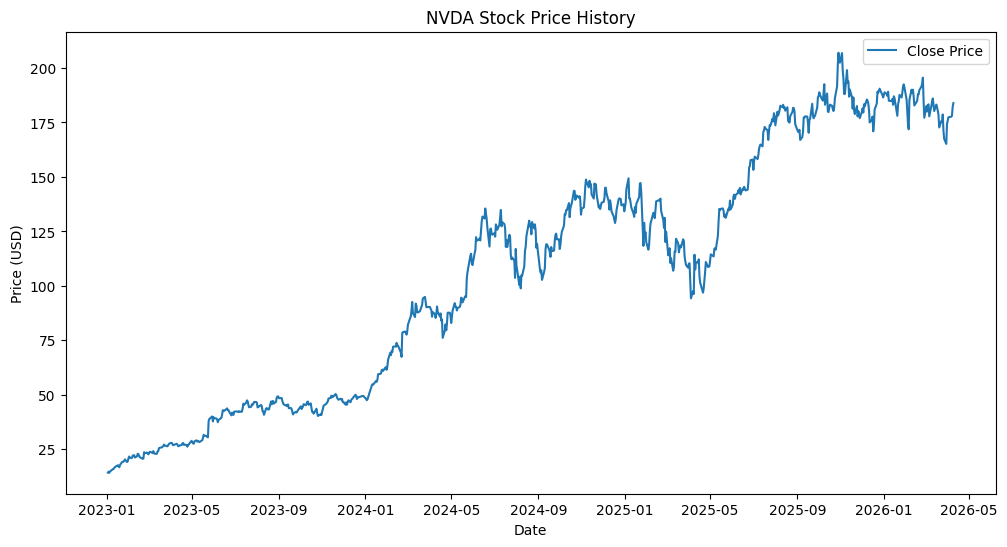

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price')
plt.title(f'{ticker} Stock Price History')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

4.Exploratory Data Analysis (EDA)

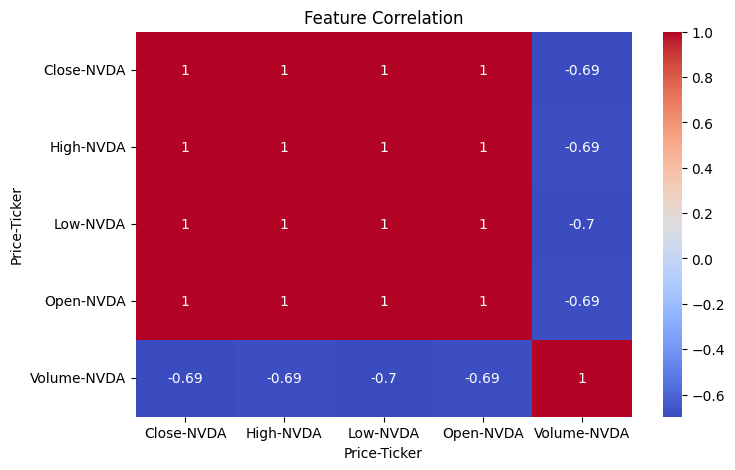

In [4]:
# Correlation matrix to see relationship between OHLC prices
plt.figure(figsize=(8, 5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

# Moving Average (Feature Engineering)
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()
data.dropna(inplace=True) # Clean up NaNs created by MA

5.Data modeling

We are using a Random Forest Regressor within a pipeline to predict the "Next Day Close Price."

In [5]:
# Initializing the Machine Learning model
# We are using Random Forest Regressor because it handles non-linear stock data well
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

# Defining the preprocessing steps (Scaling the features)
scaler = StandardScaler()

print("Data Modeling step completed: Random Forest Regressor initialized.")

Data Modeling step completed: Random Forest Regressor initialized.


6.Splitting the Data into Features and Targets

In [6]:
# We want to predict the Close price of the next day
data['Target'] = data['Close'].shift(-1)
data.dropna(inplace=True)

X = data[['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA50']]
y = data['Target']

7.Splitting the Data into Test and Training Data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8.MOdel training

In [14]:
# Combining the scaler and the model into a single pipeline for automation
pipeline = Pipeline([
    ('scaler', scaler),
    ('regressor', rf_model)
])

# Training the model using the training dataset
pipeline.fit(X_train, y_train)
print("Model Training successful!")

Model Training successful!


9.Model Evaluation

In [9]:
predictions = pipeline.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

Mean Squared Error: 11.502876469683198
R2 Score: 0.995927490124167


10.Communication and visualization

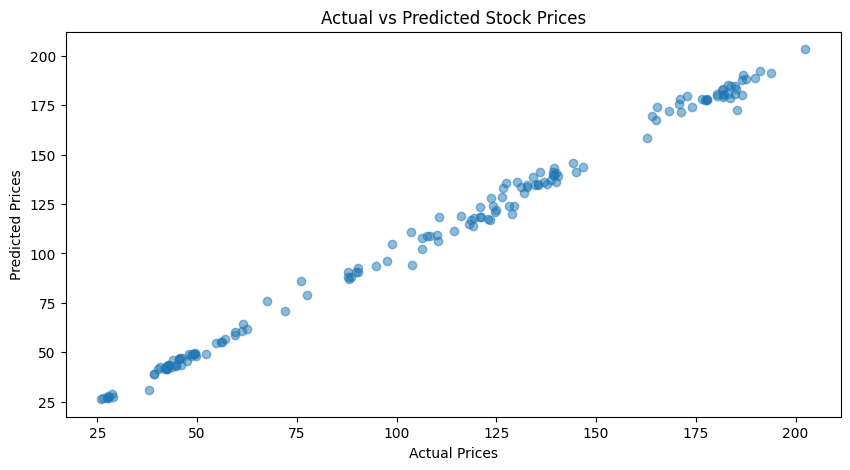

In [10]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Stock Prices')
plt.show()

11.Model Saving (.sav format)

In [11]:
# Saving the regressor part as .sav
joblib.dump(pipeline.named_steps['regressor'], 'stock_model.sav')

['stock_model.sav']

12.Data automated pipeline implementation

In [12]:
# The pipeline object already handles scaling and prediction
def predict_live(new_data):
    return pipeline.predict(new_data)

13.pipeline saving (compressed)

In [13]:
# Saving the entire pipeline (including scaler) for the app
joblib.dump(pipeline, 'full_stock_pipeline.sav', compress=3)

['full_stock_pipeline.sav']